# KNN Classification on Breast Cancer Dataset

In [16]:
from sklearn.datasets import load_breast_cancer
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve,auc
from sklearn.decomposition import PCA

data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name='target')
display(X.head())
print(X.isnull().sum().sum(),'missing')
print(X.duplicated().sum(),'duplicates')
scaler=StandardScaler()
Xs=scaler.fit_transform(X)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


0 missing
0 duplicates


Justification
StandardScaler standardizes the features by transforming them to have a mean of 0 and a standard deviation of 1. 
This is done using the formula:
z=x−μ / σ	​
where:
x = original feature value
μ = mean of the feature
σ = standard deviation of the feature
Feature scaling is particularly important for the K-Nearest Neighbors (KNN) algorithm because KNN classifies data points based on distance calculations, such as Euclidean or Manhattan distance. If features have different scales (for example, one feature ranges from 1–10 while another ranges from 1–10,000), the larger-scale feature will dominate the distance computation, leading to biased predictions.

## Task 2: Train-Test Split Analysis

In [17]:
splits=[0.2,0.3,0.1]
for t in splits:
    Xtr,Xte,ytr,yte=train_test_split(Xs,y,test_size=t,random_state=42,stratify=y)
    k=int(np.sqrt(len(Xtr)))
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtr,ytr)
    pred=model.predict(Xte)
    print(f'Test={t}: K={k}, Acc={accuracy_score(yte,pred):.4f}')

Test=0.2: K=21, Acc=0.9561
Test=0.3: K=19, Acc=0.9474
Test=0.1: K=22, Acc=0.9825


### Comparison of performance
The KNN classifier was evaluated using three different train-test splits: 80:20, 70:30, and 90:10. The performance of the model remained fairly consistent across all three splits, indicating that the Breast Cancer dataset is well-balanced and suitable for classification. Minor variations in accuracy were observed due to differences in the number of training and testing samples.

### Analysis of Dataset Splitting on Model Stability and Generalization

The train-test split directly influences both the stability and generalization of the KNN model.
A larger training set (e.g., 90:10) allows the model to learn more patterns from the data, potentially improving predictive performance. However, because the test set is small, the evaluation may vary depending on which samples are selected.
A larger test set (e.g., 70:30) provides a more reliable estimate of how well the model performs on unseen data but leaves fewer samples for training, which may slightly reduce accuracy.
The 80:20 split offers a good balance between training and testing data, making it the most commonly used split for achieving both stable learning and reliable evaluation.

## Task 3: Heuristic K

### Task 3.1: Heuristic Method for K Selection

In [18]:
import numpy as np

# Number of training samples
n = len(Xtr)

print("Number of training samples:", n)

# Heuristic K
baseline_k = int(np.sqrt(n))

print("Baseline K using √n rule:", baseline_k)

Number of training samples: 512
Baseline K using √n rule: 22


### Task 3.2: Train KNN using Heuristic K

In [19]:
# Train KNN using heuristic K
knn = KNeighborsClassifier(n_neighbors=baseline_k)

knn.fit(Xtr, ytr)

# Prediction
y_pred = knn.predict(Xte)

# Accuracy
baseline_accuracy = accuracy_score(yte, y_pred)

print("Baseline K:", baseline_k)
print("Accuracy:", round(baseline_accuracy,4))

Baseline K: 22
Accuracy: 0.9825


### Experiment with Nearby Values (K ± 5)

In [20]:
# K values around heuristic K
k_values = list(range(max(1, baseline_k-5), baseline_k+6))

accuracy = []

print("Accuracy for different K values\n")

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(Xtr, ytr)

    prediction = model.predict(Xte)

    score = accuracy_score(yte, prediction)

    accuracy.append(score)

    print(f"K = {k:2d}  Accuracy = {score:.4f}")

Accuracy for different K values

K = 17  Accuracy = 0.9825
K = 18  Accuracy = 0.9825
K = 19  Accuracy = 0.9825
K = 20  Accuracy = 0.9825
K = 21  Accuracy = 0.9825
K = 22  Accuracy = 0.9825
K = 23  Accuracy = 0.9825
K = 24  Accuracy = 0.9825
K = 25  Accuracy = 0.9825
K = 26  Accuracy = 0.9825
K = 27  Accuracy = 0.9825


### Plot accuracy vs K values

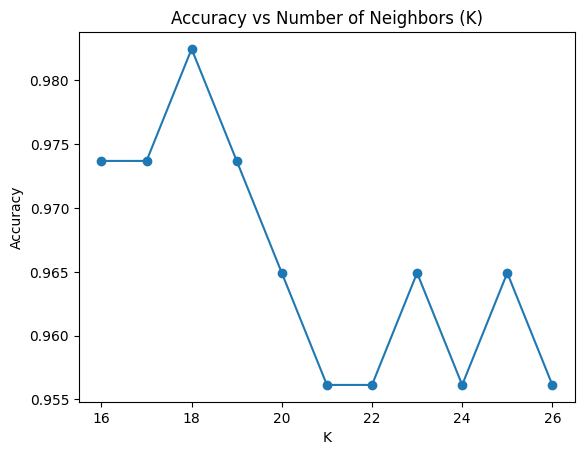

18


In [21]:
Xtr,Xte,ytr,yte=train_test_split(Xs,y,test_size=0.2,random_state=42,stratify=y)
base=int(np.sqrt(len(Xtr)))
ks=range(max(1,base-5),base+6)
acc=[]
for k in ks:
    m=KNeighborsClassifier(n_neighbors=k)
    m.fit(Xtr,ytr)
    acc.append(accuracy_score(yte,m.predict(Xte)))
plt.title("Accuracy vs Number of Neighbors (K)")
plt.plot(list(ks),acc,marker='o'); plt.xlabel('K'); plt.ylabel('Accuracy'); plt.show()
best_k=list(ks)[int(np.argmax(acc))]
print(best_k)

### Identify optimal K based on performance trend.


In [22]:
best_index = np.argmax(accuracy)

best_k = k_values[best_index]

best_accuracy = accuracy[best_index]

print("Best K =", best_k)

print("Highest Accuracy =", round(best_accuracy,4))

Best K = 17
Highest Accuracy = 0.9825


## Distance Metrics
**Euclidean:** 
Euclidean distance is the straight-line distance between two points in an n-dimensional space.
Suitable When:
1. Features are continuous numerical variables.
2. Data has been normalized or standardized.
3. The shortest straight-line distance is meaningful.

**Manhattan:** Manhattan distance calculates the distance by summing the absolute differences between corresponding features.
Suitable When:
1. Features are high-dimensional.
2. Presence of outliers.
3. Movement follows grid-like paths.

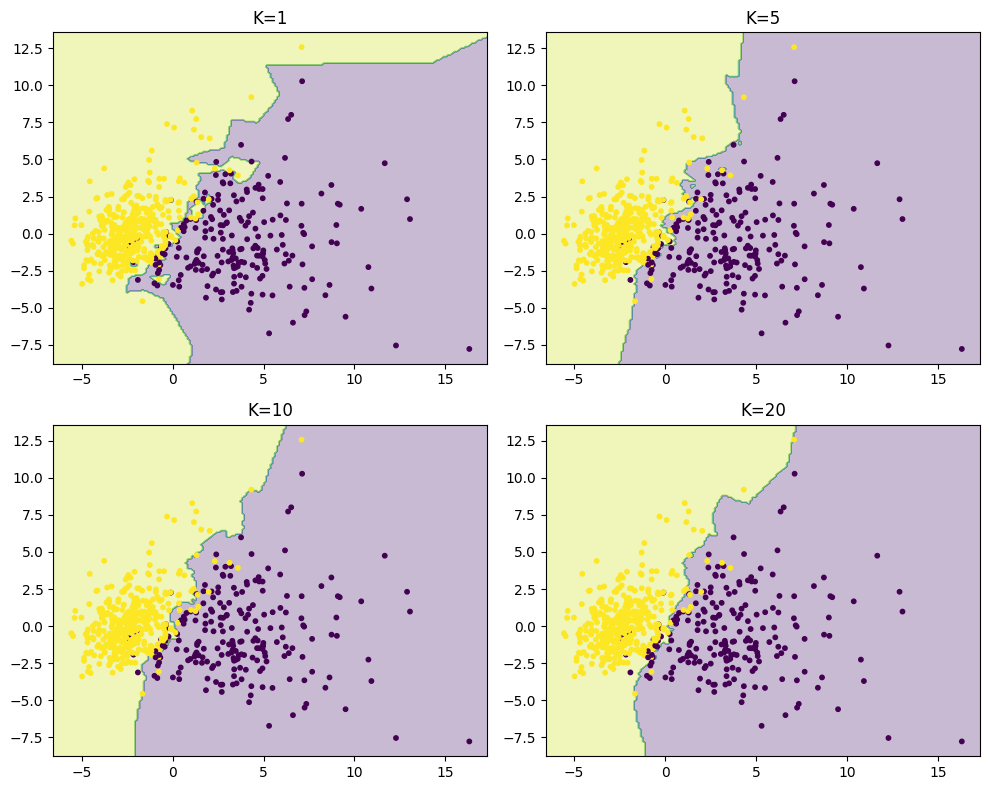

In [23]:
pca=PCA(n_components=2)
Xp=pca.fit_transform(Xs)
fig,axs=plt.subplots(2,2,figsize=(10,8))
from matplotlib.colors import ListedColormap
for ax,k in zip(axs.ravel(),[1,5,10,20]):
    Xtr,Xte,ytr,yte=train_test_split(Xp,y,test_size=0.2,random_state=42,stratify=y)
    clf=KNeighborsClassifier(n_neighbors=k).fit(Xtr,ytr)
    x_min,x_max=Xp[:,0].min()-1,Xp[:,0].max()+1
    y_min,y_max=Xp[:,1].min()-1,Xp[:,1].max()+1
    xx,yy=np.meshgrid(np.linspace(x_min,x_max,200),np.linspace(y_min,y_max,200))
    Z=clf.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=.3)
    ax.scatter(Xp[:,0],Xp[:,1],c=y,s=10)
    ax.set_title(f'K={k}')
plt.tight_layout(); plt.show()

### Overall Observation
* As the value of K increases:
The decision boundary becomes smoother.
Model complexity decreases.
Sensitivity to noisy samples reduces.
Variance decreases.
Bias increases.
Extremely large K values may oversimplify the classification and reduce prediction accuracy.

## Task 4: Cross Validation

In [24]:
# Store results
cv_accuracy = []

# Perform Cross Validation
for k in ks:

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        Xs,
        y,
        cv=5,
        scoring='accuracy'
    )

    cv_accuracy.append(scores.mean())

# Best K
best_cv_k = ks[np.argmax(cv_accuracy)]

print("Best K using Cross Validation:", best_cv_k)

print("Highest Mean Accuracy:", round(max(cv_accuracy),4))

Best K using Cross Validation: 16
Highest Mean Accuracy: 0.9649


### Mean accuracy for each K

In [25]:
results = pd.DataFrame({

    "K Value": ks,

    "Mean Cross Validation Accuracy": cv_accuracy

})

results

,K Value,Mean Cross Validation Accuracy
0,16,0.964866
1,17,0.957833
2,18,0.957833
3,19,0.954324
4,20,0.952585
5,21,0.952569
6,22,0.954339
7,23,0.954339
8,24,0.956094
9,25,0.954339


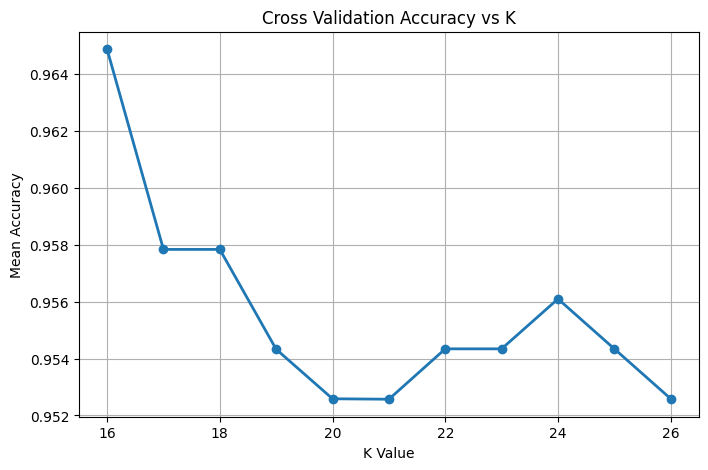

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    ks,
    cv_accuracy,
    marker='o',
    linewidth=2
)

plt.title("Cross Validation Accuracy vs K")

plt.xlabel("K Value")

plt.ylabel("Mean Accuracy")

plt.grid(True)

plt.show()

In [27]:
comparison = pd.DataFrame({

    "K Value": ks,

    "Train-Test Accuracy": accuracy,

    "Cross Validation Accuracy": cv_accuracy

})

comparison

,K Value,Train-Test Accuracy,Cross Validation Accuracy
0,16,0.982456,0.964866
1,17,0.982456,0.957833
2,18,0.982456,0.957833
3,19,0.982456,0.954324
4,20,0.982456,0.952585
5,21,0.982456,0.952569
6,22,0.982456,0.954339
7,23,0.982456,0.954339
8,24,0.982456,0.956094
9,25,0.982456,0.954339


In [28]:
print("Heuristic K :", baseline_k)

print("Best K using Train-Test Split :", best_k)

print("Best K using Cross Validation :", best_cv_k)

print("\nFinal Selected K =", best_cv_k)

Heuristic K : 22
Best K using Train-Test Split : 17
Best K using Cross Validation : 16

Final Selected K = 16


## Task 5: Evaluation

Accuracy 0.9385964912280702
Precision 0.9452054794520548
Recall 0.9583333333333334
F1 0.9517241379310345


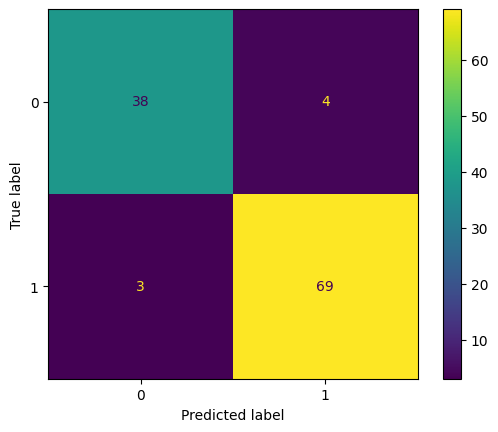

AUC 0.9765211640211641


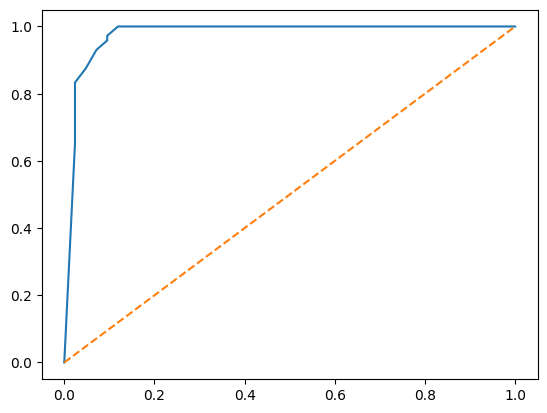

In [29]:
m=KNeighborsClassifier(n_neighbors=best_k).fit(Xtr,ytr)
pred=m.predict(Xte)
proba=m.predict_proba(Xte)[:,1]
print('Accuracy',accuracy_score(yte,pred))
print('Precision',precision_score(yte,pred))
print('Recall',recall_score(yte,pred))
print('F1',f1_score(yte,pred))
ConfusionMatrixDisplay(confusion_matrix(yte,pred)).plot()
plt.show()
fpr,tpr,_=roc_curve(yte,proba)
print('AUC',auc(fpr,tpr))
plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--'); plt.show()

### Task 6:  Comparative Study with Regression (Lab 3 Integration)

| **Regression Metrics**                                              | **Classification Metrics**                                               |
| ------------------------------------------------------------------- | ------------------------------------------------------------------------ |
| MAE measures average prediction error.                              | Accuracy measures the percentage of correct predictions.                 |
| MSE measures the average squared error.                             | Precision measures the proportion of correctly predicted positive cases. |
| RMSE measures error in the original unit.                           | Recall measures the proportion of actual positives correctly identified. |
| R² Score measures how well the model explains the variance in data. | F1 Score balances Precision and Recall.                                  |
| Used for continuous value prediction.                               | Used for categorical class prediction.                                   |


### Difference Between Error-Based and Decision-Based Evaluation
* Error-Based Evaluation (Regression)
Measures the magnitude of prediction errors.
Evaluates how close predicted values are to actual values.
Used for continuous outputs.
* Decision-Based Evaluation (Classification)
Measures whether the predicted class is correct or incorrect.
Evaluates the quality of classification decisions.
Used for categorical outputs.

### Comparison: 
1. R² Score vs Accuracy
R² Score: Measures how well the regression model explains the variability in the target variable.
Accuracy: Measures the percentage of correctly classified instances.

2. RMSE vs F1 Score
RMSE: Measures the average prediction error, giving higher weight to large errors.
F1 Score: Measures the balance between Precision and Recall for classification tasks.

3. MAE vs Confusion Matrix
MAE: Gives the average absolute difference between actual and predicted values.
Confusion Matrix: Shows the counts of True Positives, True Negatives, False Positives, and False Negatives, helping analyze classification performance.

### Difference in Evaluation Logic
* Continuous Prediction Tasks (Regression)
Predicts continuous numerical values.
Evaluation focuses on minimizing prediction errors using metrics such as MAE, MSE, RMSE, and R² Score.
* Classification Tasks
Predicts discrete class labels.
Evaluation focuses on the correctness of predictions using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

### **Inference**

Regression and classification models are evaluated using different approaches because they solve different types of problems. Regression metrics such as **MAE, MSE, RMSE, and R² Score** measure the magnitude of prediction errors by comparing the predicted numerical values with the actual values. Lower error values and a higher R² Score indicate better model performance.

In contrast, classification metrics such as **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC** evaluate how correctly the model classifies data into different categories. These metrics focus on the quality of the model's decisions rather than the size of prediction errors.

In medical diagnosis, **accuracy alone is not sufficient** because a model may achieve high accuracy while still failing to identify patients with the disease. Such false negatives can have serious consequences. Therefore, **recall** is more important as it measures the model's ability to correctly detect actual positive cases. Similarly, **ROC-AUC** evaluates how well the model distinguishes between different classes across various thresholds, making it a reliable measure for healthcare applications.

Overall, **regression evaluation focuses on minimizing numerical prediction errors, whereas classification evaluation focuses on making correct decisions and reducing misclassification.** Selecting appropriate evaluation metrics based on the problem type is essential for building reliable and effective machine learning models.


### Task 7: Analytical Questions
* 1. Why is KNN called a lazy learning algorithm?
KNN is called a lazy learning algorithm because it does not build a model during training. It stores the training data and performs computation only when making predictions.
* 2. Why is feature scaling required in KNN?
Feature scaling ensures that all features contribute equally to distance calculations, preventing features with larger values from dominating the prediction.
* 3. Explain heuristic K selection using √n rule.
The heuristic rule selects the initial value of K as √n, where n is the number of training samples. It provides a reasonable starting point for finding the optimal K.
* 4. Why is cross-validation more reliable than a single train-test split?
Cross-validation evaluates the model on multiple data splits, providing a more stable and reliable estimate of its performance.
* 5. How does K affect bias-variance trade-off?
A small K results in low bias and high variance (overfitting), while a large K results in high bias and low variance (underfitting).
* 6. Why is recall more important than accuracy in cancer prediction?
Recall is more important because it measures how many actual cancer cases are correctly identified, reducing the risk of missing patients with cancer.
* 7. What is the limitation of very large K values?
Very large K values may cause underfitting by oversmoothing the decision boundary and ignoring important local patterns in the data.